In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('/Users/qiaoqiao/Desktop/Documents/Company and online projects/Kaggle A:B testing project/ab_testing_kaggle_marketing/data/raw/marketing_AB.csv')

In [2]:
#data general info 
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [3]:
#The dataset contains 588,101 rows and appears to be one row per unique user. 
#No null values were found in any column, and no duplicate user IDs were found. 
#The outcome variable `converted` is boolean. The dataset includes two groups: `ad` and `psa`, with a much larger treatment group than control group.

In [4]:
df = df.rename(columns = {'user id': 'user_id',
                                'test group': 'test_group',
                                'total ads': 'total_ads',
                                'most ads day': 'most_ads_day',
                                'most ads hour': 'most_ads_hour'})
df['converted_flag'] = df['converted'].astype(int)

In [5]:
df.drop(columns=['Unnamed: 0'])

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,converted_flag
0,1069124,ad,False,130,Monday,20,0
1,1119715,ad,False,93,Tuesday,22,0
2,1144181,ad,False,21,Tuesday,18,0
3,1435133,ad,False,355,Tuesday,10,0
4,1015700,ad,False,276,Friday,14,0
...,...,...,...,...,...,...,...
588096,1278437,ad,False,1,Tuesday,23,0
588097,1327975,ad,False,1,Tuesday,23,0
588098,1038442,ad,False,3,Tuesday,23,0
588099,1496395,ad,False,1,Tuesday,23,0


In [6]:
#data QA
qa_summary = pd.Series({
    'rows': len(df),
    'columns': df.shape[1],
    'duplicate_user_ids': df['user_id'].duplicated().sum(),
    'missing_values': df.isna().sum().sum(),
    'min_total_ads': df['total_ads'].min(),
    'max_total_ads': df['total_ads'].max(),
    'min_most_ads_hour': df['most_ads_hour'].min(),
    'max_most_ads_hour': df['most_ads_hour'].max()
})

qa_summary

rows                  588101
columns                    8
duplicate_user_ids         0
missing_values             0
min_total_ads              1
max_total_ads           2065
min_most_ads_hour          0
max_most_ads_hour         23
dtype: int64

In [7]:
#conversions for each group
group_summary = df.groupby('test_group').agg(users=('user_id', 'nunique'), 
                                             conversions=('converted_flag', 'sum'),
                                             conversion_rate=('converted_flag', 'mean'),
                                             avg_total_ads = ('total_ads', 'mean'),
                                             median_total_ads = ('total_ads', 'median')).reset_index()
group_summary

,test_group,users,conversions,conversion_rate,avg_total_ads,median_total_ads
0,ad,564577,14423,0.025547,24.823365,13.0
1,psa,23524,420,0.017854,24.761138,12.0


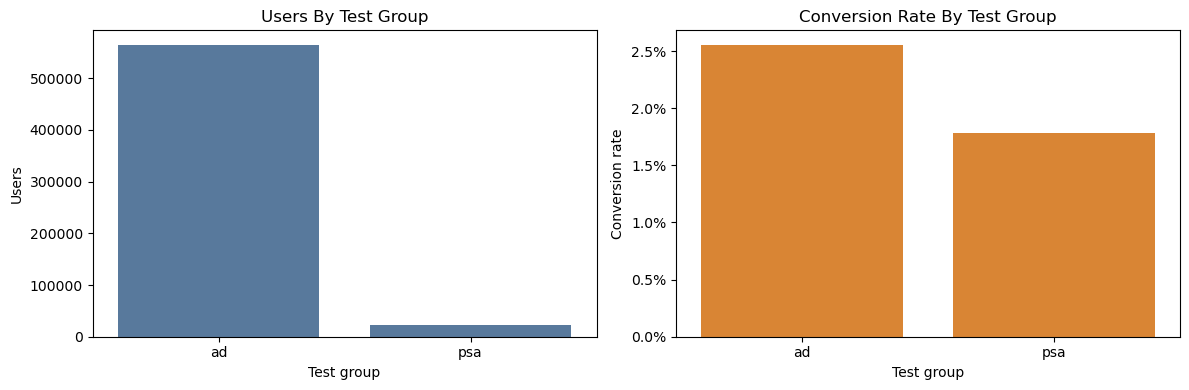

In [8]:
#test group size and conversion rate
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=group_summary, x='test_group', y='users', ax=axes[0], color='#4C78A8')
axes[0].set_title('Users By Test Group')
axes[0].set_xlabel('Test group')
axes[0].set_ylabel('Users')

sns.barplot(data=group_summary, x='test_group', y='conversion_rate', ax=axes[1], color='#F58518')
axes[1].set_title('Conversion Rate By Test Group')
axes[1].set_xlabel('Test group')
axes[1].set_ylabel('Conversion rate')
axes[1].yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')

plt.tight_layout()

In [9]:
#A/B test results
ad = group_summary[group_summary['test_group'] == 'ad'].iloc[0]
psa = group_summary[group_summary['test_group'] == 'psa'].iloc[0]

conversions = np.array([ad['conversions'], psa['conversions']])
users = np.array([ad['users'], psa['users']])

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users,
    alternative='larger'
)

ad_rate = ad['conversion_rate']
psa_rate = psa['conversion_rate']
absolute_lift = ad_rate - psa_rate
relative_lift = absolute_lift / psa_rate
incremental_conversions = (absolute_lift * ad['users']).round(2)

ab_results = pd.Series({
    'ad_conversion_rate': ad_rate,
    'psa_conversion_rate': psa_rate,
    'absolute_lift': absolute_lift,
    'relative_lift': relative_lift,
    'incremental_conversions': incremental_conversions,
    'z_stat': z_stat,
    'one_sided_p_value': p_value
})

ab_results

ad_conversion_rate         2.554656e-02
psa_conversion_rate        1.785411e-02
absolute_lift              7.692453e-03
relative_lift              4.308506e-01
incremental_conversions    4.342980e+03
z_stat                     7.370078e+00
one_sided_p_value          8.526404e-14
dtype: float64

In [10]:
#hypothesis: H0: p_ad <= p_psa
#            H1: p_ad > p_psa
#Because the p-value is much less than 0.05, we reject the null hypothesis.
#There is statistically significant evidence that the ad group had a higher conversion rate than the PSA/control group.
#Q1: Would the campaign be successful?
#To evaluate whether the campaign was successful, 
#I ran a one-sided two-proportion z-test comparing conversion rates between the ad group and the PSA control group.
#The test returned z = 7.37 and p < 0.001. Since the p-value is below 0.05, 
#I reject the null hypothesis and conclude that the ad campaign produced a statistically significant increase in conversion rate.
#Q2: If the campaign was successful, how much of that success could be attributed to the ads?
#The ad group converted at 2.55%, compared with 1.79% for the PSA group. 
#This is an absolute lift of about 0.77 percentage points, or a relative lift of about 43.1%. 
#Applied to the 564,577 users in the ad group, this suggests approximately 4,343 conversions can be attributed to the ads.

In [11]:
#conversion rate by weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_group_summary = (
    df
    .groupby(['test_group', 'most_ads_day'])
    .agg(
        users=('user_id', 'count'),
        conversions=('converted_flag', 'sum'),
        conversion_rate=('converted_flag', 'mean')
    )
    .reset_index()
)

weekday_group_summary

,test_group,most_ads_day,users,conversions,conversion_rate
0,ad,Friday,88805,1995,0.022465
1,ad,Monday,83571,2778,0.033241
2,ad,Saturday,78802,1679,0.021307
3,ad,Sunday,82332,2027,0.024620
4,ad,Thursday,79077,1711,0.021637
5,ad,Tuesday,74572,2270,0.030440
6,ad,Wednesday,77418,1963,0.025356
7,psa,Friday,3803,62,0.016303
8,psa,Monday,3502,79,0.022559
9,psa,Saturday,2858,40,0.013996


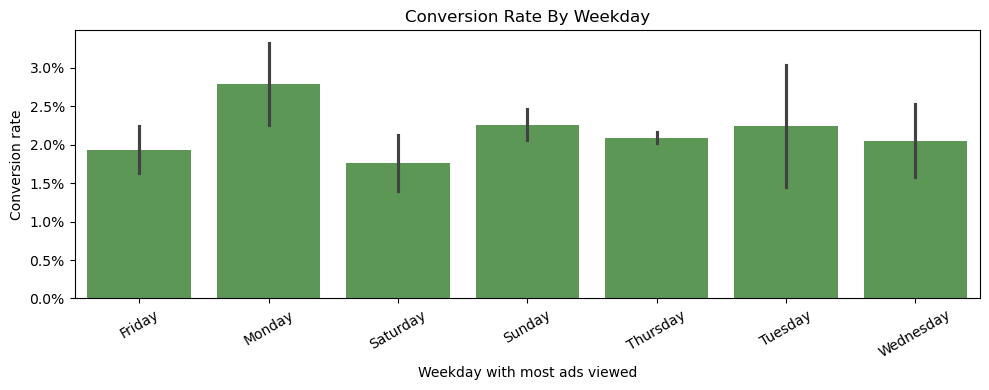

In [12]:
#bar chart for week day and conversion rate
plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_group_summary, x='most_ads_day', y='conversion_rate', color='#54A24B')
plt.title('Conversion Rate By Weekday')
plt.xlabel('Weekday with most ads viewed')
plt.ylabel('Conversion rate')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
plt.xticks(rotation=30)
plt.tight_layout()

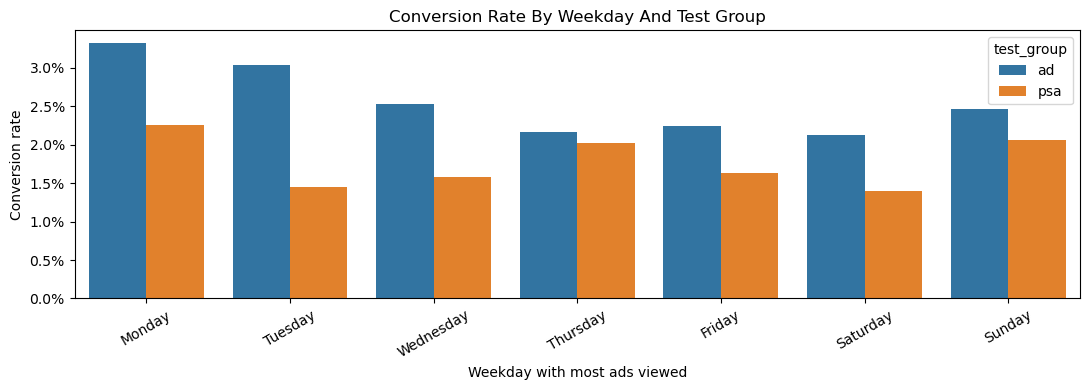

In [13]:
#bar chart for test groups on each weekday and conversion rate
plt.figure(figsize=(11, 4))

sns.barplot(
    data=weekday_group_summary,
    x='most_ads_day',
    y='conversion_rate',
    hue='test_group',
    order=day_order
)

plt.title('Conversion Rate By Weekday And Test Group')
plt.xlabel('Weekday with most ads viewed')
plt.ylabel('Conversion rate')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
plt.xticks(rotation=30)
plt.tight_layout()

In [14]:
#chi-square test for weekdays and conversion rate
contingency_table = pd.crosstab(df['most_ads_day'], df['converted_flag']).reindex(day_order)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

pd.Series({
    'chi_square': chi2,
    'degrees_of_freedom': dof,
    'p_value': p_value
})

chi_square            4.100479e+02
degrees_of_freedom    6.000000e+00
p_value               1.932184e-85
dtype: float64

In [15]:
#conclusion:
#There is statistically significant evidence that conversion is associated with weekday.

In [16]:
#conversion rate by hour
hour_summary = df.groupby('most_ads_hour').agg(users=('user_id', 'count'),
                                               conversions=('converted_flag', 'sum'),
                                               conversion_rate=('converted_flag', 'mean')).reset_index().sort_values(by='most_ads_hour')

hour_summary

,most_ads_hour,users,conversions,conversion_rate
0,0,5536,102,0.018425
1,1,4802,62,0.012911
2,2,5333,39,0.007313
3,3,2679,28,0.010452
4,4,722,11,0.015235
5,5,765,16,0.020915
6,6,2068,46,0.022244
7,7,6405,116,0.018111
8,8,17627,344,0.019516
9,9,31004,595,0.019191


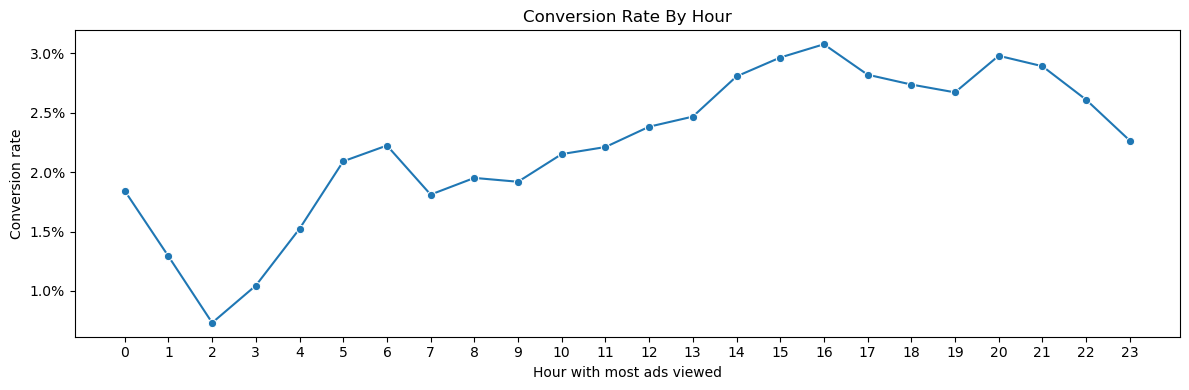

In [17]:
#line plot of conversion rate by hour
plt.figure(figsize=(12, 4))
sns.lineplot(data=hour_summary, x='most_ads_hour', y='conversion_rate', marker='o')
plt.title('Conversion Rate By Hour')
plt.xlabel('Hour with most ads viewed')
plt.ylabel('Conversion rate')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
plt.xticks(range(0, 24))
plt.tight_layout()

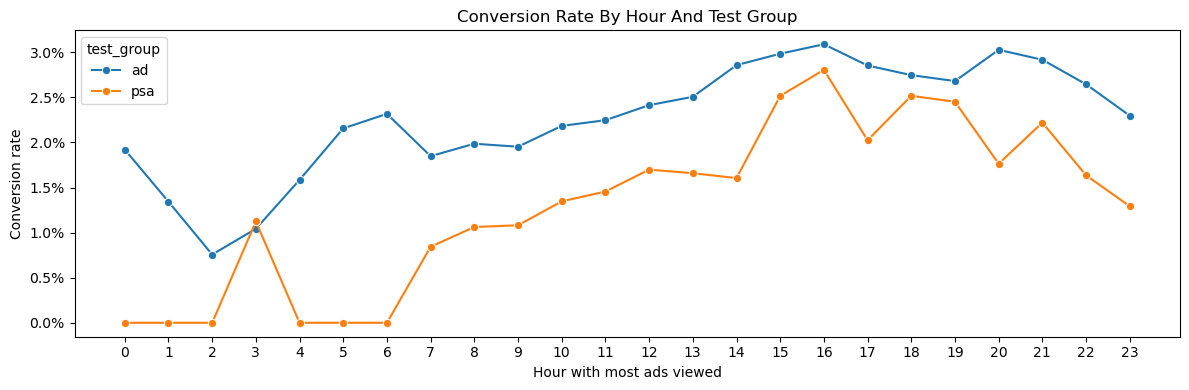

In [18]:
#line plot of conversion rate by hour and test group
hour_group_summary = (
    df
    .groupby(['test_group', 'most_ads_hour'])
    .agg(
        users=('user_id', 'count'),
        conversions=('converted_flag', 'sum'),
        conversion_rate=('converted_flag', 'mean')
    )
    .reset_index()
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=hour_group_summary, x='most_ads_hour', y='conversion_rate', hue='test_group', marker='o')
plt.title('Conversion Rate By Hour And Test Group')
plt.xlabel('Hour with most ads viewed')
plt.ylabel('Conversion rate')
plt.gca().yaxis.set_major_formatter(lambda x, pos: f'{x:.1%}')
plt.xticks(range(0, 24))
plt.tight_layout()

In [19]:
#chi-square test for hours and conversion rate
contingency_hour_table = pd.crosstab(df['most_ads_hour'], df['converted_flag'])

hour_chi2, hour_p_value, hour_dof, hour_expected = chi2_contingency(contingency_hour_table)

pd.Series({
    'chi_square': hour_chi2,
    'degrees_of_freedom': hour_dof,
    'p_value': hour_p_value
})

chi_square            4.307687e+02
degrees_of_freedom    2.300000e+01
p_value               8.027630e-77
dtype: float64

In [20]:
#conclusion:
#There is statistically significant evidence that conversion is associated with hour of day.

In [21]:
top_weekdays = weekday_group_summary.sort_values('conversion_rate', ascending=False)
top_hours = hour_summary.sort_values('conversion_rate', ascending=False).head(10)

top_weekdays, top_hours

(   test_group most_ads_day  users  conversions  conversion_rate
 1          ad       Monday  83571         2778         0.033241
 5          ad      Tuesday  74572         2270         0.030440
 6          ad    Wednesday  77418         1963         0.025356
 3          ad       Sunday  82332         2027         0.024620
 8         psa       Monday   3502           79         0.022559
 0          ad       Friday  88805         1995         0.022465
 4          ad     Thursday  79077         1711         0.021637
 2          ad     Saturday  78802         1679         0.021307
 10        psa       Sunday   3059           63         0.020595
 11        psa     Thursday   3905           79         0.020230
 7         psa       Friday   3803           62         0.016303
 13        psa    Wednesday   3490           55         0.015759
 12        psa      Tuesday   2907           42         0.014448
 9         psa     Saturday   2858           40         0.013996,
     most_ads_hour  user